<a href="https://colab.research.google.com/github/karamathasan/3D-graphing/blob/main/naive_fold.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
train_sequences = pd.read_csv("/content/drive/MyDrive/Colab Data/RNA/train_sequences.csv")
train_labels = pd.read_csv("/content/drive/MyDrive/Colab Data/RNA/train_labels.csv")

validation_sequences = pd.read_csv("/content/drive/MyDrive/Colab Data/RNA/validation_sequences.csv")
validation_labels = pd.read_csv("/content/drive/MyDrive/Colab Data/RNA/validation_labels.csv")

In [4]:
train_labels.tail()

,ID,resname,resid,x_1,y_1,z_1
137090,8Z1F_T_82,U,82,NaN,NaN,NaN
137091,8Z1F_T_83,C,83,NaN,NaN,NaN
137092,8Z1F_T_84,A,84,NaN,NaN,NaN
137093,8Z1F_T_85,U,85,NaN,NaN,NaN
137094,8Z1F_T_86,A,86,NaN,NaN,NaN


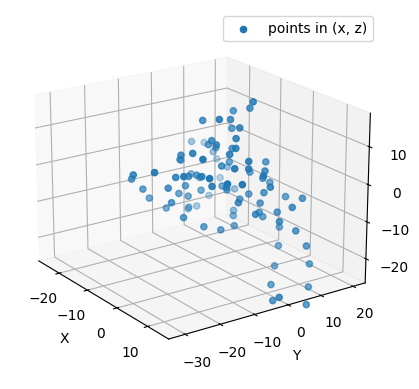

In [5]:
import matplotlib.pyplot as plt
import numpy as np

ax = plt.figure().add_subplot(projection='3d')

num_points = 100
x = train_labels['x_1'][:num_points]
y = train_labels['y_1'][:num_points]
z = train_labels['z_1'][:num_points]

ax.scatter(x, y, z, zdir='y', label='points in (x, z)')

ax.legend()

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

ax.view_init(elev=20., azim=-35, roll=0)


In [6]:
def encode_sequence(sequence):
    mapping = {'A': [1., 0., 0., 0.],
               'U': [0., 1., 0., 0.],
               'C': [0., 0., 1., 0.],
               'G': [0., 0., 0., 1.],
               'X': [0., 0., 0., 0.],
               '-': [0., 0., 0., 0.]}

    output = np.array([mapping[nuc] for nuc in sequence])
    return output.T

In [122]:
from torch.nn import Conv1d, Conv2d, Sequential, ReLU, MaxPool2d, MaxPool1d, Flatten, Linear, functional, BatchNorm1d, BatchNorm2d, BatchNorm3d

model = Conv1d(in_channels=4, out_channels=3, kernel_size=5, stride=1, padding='same')



In [142]:
class RNAConv(torch.nn.Module):
  def __init__(self):
    super().__init__()

    # self.conv1 = Conv1d(in_channels=4, out_channels=3, kernel_size=5, stride=1, padding='same')
    # self.batch1 = BatchNorm1d(3)

    self.conv1 = Conv1d(in_channels=4, out_channels=9, kernel_size=5, stride=1, padding='same')
    # self.batch1 = BatchNorm1d(27)
    self.pool1 = MaxPool1d(kernel_size=5, stride=1, padding=2)

    self.conv2 = Conv1d(in_channels=9, out_channels=3, kernel_size=5, stride=1, padding='same')
    # self.batch2 = BatchNorm1d(9)
    self.pool2 = MaxPool1d(kernel_size=5, stride=1, padding=2)

    # self.conv3 = Conv1d(in_channels=9, out_channels=3, kernel_size=5, stride=1, padding='same')
    # self.batch3 = BatchNorm1d(3)
    # self.pool3 = MaxPool1d(kernel_size=3, stride=1, padding=1)

  def forward(self, x):
    x = self.conv1(x)
    # x = self.batch1(x)
    x = self.pool1(x)

    x = self.conv2(x)
    # x = self.batch2(x)
    x = self.pool2(x)

    # x = self.conv3(x)
    # x = self.batch3(x)
    # x = self.pool3(x)

    return x

In [143]:
newModel = RNAConv()

In [10]:
train_labels.fillna(0, inplace=True)
validation_labels.fillna(0, inplace=True)

In [11]:
Xtrain = [torch.tensor(encode_sequence(s), dtype = torch.float32).unsqueeze(0) for s in train_sequences[['sequence']].values[:,0]]
ytrain = [torch.tensor(train_labels.loc[train_labels['ID'].str.startswith(l)][['x_1', 'y_1', 'z_1']].values, dtype=torch.float32) for l in train_sequences["target_id"]]

In [12]:
Xval = [torch.tensor(encode_sequence(s), dtype = torch.float32).unsqueeze(0) for s in validation_sequences[['sequence']].values[:,0]]
yval = [torch.tensor(validation_labels.loc[validation_labels['ID'].str.startswith(l)][['x_1', 'y_1', 'z_1']].values, dtype=torch.float32) for l in validation_sequences["target_id"]]

In [ ]:
print(len(Xtrain))
print(len(ytrain))
print(len(Xval))
print(len(yval))

844
844
12
12


In [144]:
from torch.optim import Adam
from torch.nn import MSELoss

lossfn = MSELoss()
opt = Adam(model.parameters(), lr=0.001)

newOpt = Adam(newModel.parameters(), lr=0.0001)

In [101]:
model.train(True)
epochs = 50
for epoch in range(epochs):
  i = 0
  total_loss = 0
  for X in Xtrain:
    opt.zero_grad()
    output = model(X)

    loss = lossfn(output, ytrain[i].T.unsqueeze(0))
    loss.backward()

    opt.step()
    total_loss += loss.item()
    i+=1
  print(total_loss)


KeyboardInterrupt: 

In [146]:
newModel.train(True)
epochs = 20
for epoch in range(epochs):
  i = 0
  total_loss = 0
  for X in Xtrain:
    newOpt.zero_grad()
    output = newModel(X)

    loss = lossfn(output, ytrain[i].T.unsqueeze(0))
    loss.backward()

    newOpt.step()
    total_loss += loss.item()
    i+=1
  print(total_loss)


9404161.039488358
9253904.087091804
9037700.99793911
8799660.755010605
8571119.449680328
8369218.667201996
8201156.429691315
8067608.882591248
7965411.460929871
7889596.784065247
7834769.5916900635
7795916.851448059
7768813.671340942
7750105.225509644
7737275.276817322
7728501.981163025
7722441.709358215
7718172.794181824
7715078.796310425
7712753.987571716


In [137]:
seq = Xval[0]
newout = model(seq)

In [ ]:
print(newout.shape)
print(yval[0].T.shape)


torch.Size([1, 3, 69])
torch.Size([3, 69])


In [17]:
def plot_difference(validation_coord, pred_coord):
  ax = plt.figure().add_subplot(projection='3d')

  # num_points = 100
  vx = validation_coord[:, 0]
  vy = validation_coord[:, 1]
  vz = validation_coord[:, 2]

  px = pred_coord[:, 0]
  py = pred_coord[:, 1]
  pz = pred_coord[:, 2]

  ax.scatter(vx, vy, vz, zdir='y', label='points in (x, z)')
  ax.scatter(px, py, pz, zdir='y', c='red', label='points in (x, z)')

  ax.legend()

  ax.set_xlabel('X')
  ax.set_ylabel('Y')
  ax.set_zlabel('Z')

  ax.view_init(elev=45., azim=-45, roll=0)

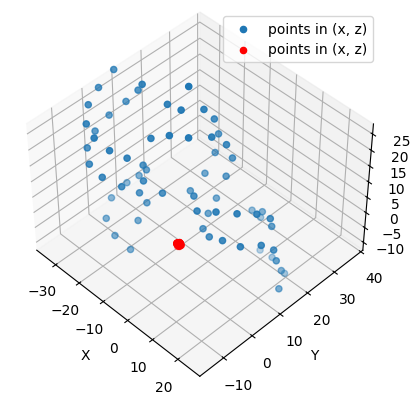

In [ ]:
plot_difference(yval[0], newout[0].T.detach().numpy())

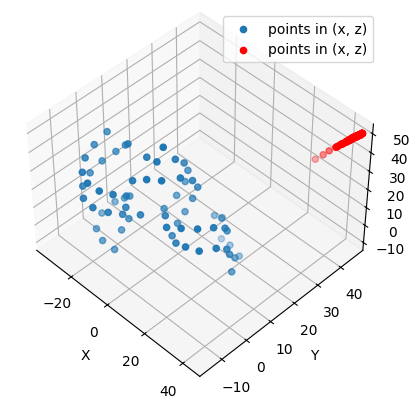

In [147]:
seq = Xval[0]
newModelOut = newModel(seq)

plot_difference(yval[0], newModelOut[0].T.detach().numpy())